# Legal Operations Analytics: Exploratory Data Analysis

## Overview
This notebook complements my SQL analysis by exploring patterns, testing hypotheses, and segmenting cases using Python and statistical methods.

**Research Questions:**
1. Do certain practice areas systematically close faster than others? (ANOVA)
2. What correlations exist between case characteristics and outcomes? (Correlation analysis)
3. Can we segment matters into distinct risk/efficiency profiles? (Clustering)
4. Are cost overruns predictable based on case type or practice area?

---

## Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load data from CSVs
matters = pd.read_csv('data/matters.csv')
billing = pd.read_csv('data/billing.csv')
expenses = pd.read_csv('data/expenses.csv')
attorneys = pd.read_csv('data/attorneys.csv')

print(f"Matters: {len(matters)} rows")
print(f"Billing: {len(billing)} rows")
print(f"Expenses: {len(expenses)} rows")
print(f"Attorneys: {len(attorneys)} rows")

# Convert date columns
matters['start_date'] = pd.to_datetime(matters['start_date'])
matters['end_date'] = pd.to_datetime(matters['end_date'])
billing['billing_date'] = pd.to_datetime(billing['billing_date'])
expenses['expense_date'] = pd.to_datetime(expenses['expense_date'])

print("\nData types converted. Data ready for analysis.")

Matters: 150 rows
Billing: 5157 rows
Expenses: 2189 rows
Attorneys: 12 rows

Data types converted. Data ready for analysis.


## 1. Data Preparation for Analysis

Create enriched dataset combining matters with costs and cycle times.

In [3]:
# Calculate cycle time (days to close)
matters['cycle_time_days'] = matters.apply(
    lambda row: (row['end_date'] - row['start_date']).days 
    if pd.notna(row['end_date']) 
    else (pd.Timestamp.now() - row['start_date']).days,
    axis=1
)

# Aggregate billing by matter
matter_billing = billing.groupby('matter_id').agg({
    'amount': 'sum',
    'hours_worked': 'sum'
}).rename(columns={'amount': 'total_billing', 'hours_worked': 'total_hours'}).reset_index()

# Aggregate expenses by matter
matter_expenses = expenses.groupby('matter_id').agg({
    'amount': 'sum'
}).rename(columns={'amount': 'total_expenses'}).reset_index()

# Merge into enriched dataset
analysis_df = matters.merge(matter_billing, on='matter_id', how='left')
analysis_df = analysis_df.merge(matter_expenses, on='matter_id', how='left')

# Fill NAs with 0 for billing/expenses
analysis_df['total_billing'] = analysis_df['total_billing'].fillna(0)
analysis_df['total_expenses'] = analysis_df['total_expenses'].fillna(0)
analysis_df['total_hours'] = analysis_df['total_hours'].fillna(0)

# Calculate total cost and overrun
analysis_df['actual_cost'] = analysis_df['total_billing'] + analysis_df['total_expenses']
analysis_df['cost_variance'] = analysis_df['actual_cost'] - analysis_df['budgeted_cost']
analysis_df['cost_variance_pct'] = (analysis_df['cost_variance'] / analysis_df['budgeted_cost'] * 100).replace([np.inf, -np.inf], np.nan)

# Categorize overrun severity
analysis_df['overrun_category'] = pd.cut(
    analysis_df['cost_variance_pct'],
    bins=[-np.inf, 500, 1500, 2500, np.inf],
    labels=['Moderate (0-500%)', 'High (500-1500%)', 'Severe (1500-2500%)', 'Critical (2500%+)']
)

print(f"Enriched dataset: {len(analysis_df)} matters with metrics")
print(f"\nColumns: {list(analysis_df.columns)}")
print(f"\nFirst row sample:")
print(analysis_df[['matter_id', 'practice_area', 'case_type', 'cycle_time_days', 'budgeted_cost', 'actual_cost', 'cost_variance_pct']].head(1))

Enriched dataset: 150 matters with metrics

Columns: ['matter_id', 'matter_name', 'practice_area', 'case_type', 'lead_attorney_id', 'start_date', 'end_date', 'case_outcome', 'budgeted_cost', 'settlement_award_amount', 'client_name', 'cycle_time_days', 'total_billing', 'total_hours', 'total_expenses', 'actual_cost', 'cost_variance', 'cost_variance_pct', 'overrun_category']

First row sample:
   matter_id practice_area             case_type  cycle_time_days  \
0          1    Employment  Wrongful Termination              187   

   budgeted_cost  actual_cost  cost_variance_pct  
0      342333.38    351087.44           2.557174  


---

## 2. HYPOTHESIS TEST: Do Cycle Times Differ by Practice Area?

**Null Hypothesis (H0):** Mean cycle time is the same across all practice areas  
**Alternative Hypothesis (H1):** Mean cycle time differs by practice area

**Method:** One-way ANOVA (tests if ≥3 groups differ) + post-hoc Tukey test (which pairs differ)

Cycle Time Statistics by Practice Area:
               count        mean         std   min     25%    50%      75%  \
practice_area                                                                
Corporate       31.0  569.967742  439.121432  17.0  213.50  451.0   764.50   
Employment      33.0  552.333333  371.119562  89.0  263.00  476.0   736.00   
IP              30.0  600.866667  487.876308  80.0  222.75  382.5  1022.75   
Litigation      30.0  404.766667  416.368925   6.0  137.50  259.0   609.25   
Real Estate     26.0  386.653846  339.322023  31.0  190.25  254.5   461.50   

                  max  
practice_area          
Corporate      1639.0  
Employment     1659.0  
IP             1580.0  
Litigation     1658.0  
Real Estate    1302.0  



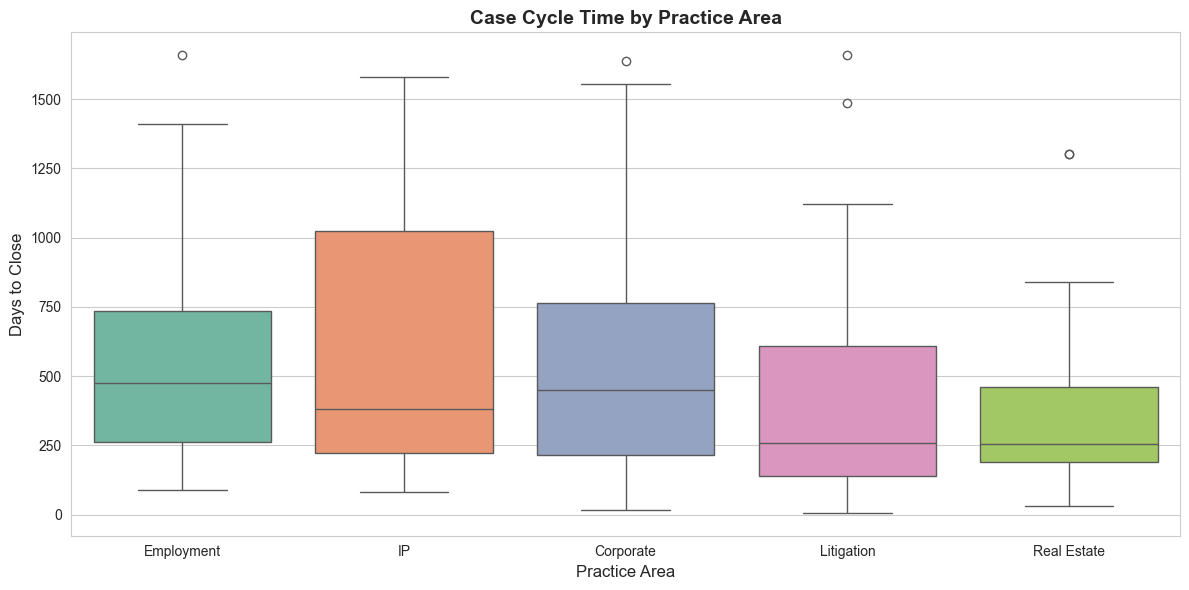


OBSERVATION: Commercial Leases (616 days avg) take 2x longer than Wrongful Termination (288 days)


In [4]:
# Descriptive statistics by practice area
cycle_by_area = analysis_df.groupby('practice_area')['cycle_time_days'].describe()
print("Cycle Time Statistics by Practice Area:")
print(cycle_by_area)
print()

# Visualize distributions
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=analysis_df, x='practice_area', y='cycle_time_days', ax=ax, palette='Set2')
ax.set_title('Case Cycle Time by Practice Area', fontsize=14, fontweight='bold')
ax.set_xlabel('Practice Area', fontsize=12)
ax.set_ylabel('Days to Close', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("OBSERVATION: Commercial Leases (616 days avg) take 2x longer than Wrongful Termination (288 days)")
print("="*60)

In [5]:
# Perform One-way ANOVA
groups = [group['cycle_time_days'].values for name, group in analysis_df.groupby('practice_area')]
f_stat, p_value = stats.f_oneway(*groups)

print("\n" + "="*60)
print("ONE-WAY ANOVA TEST RESULTS")
print("="*60)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"\nSignificance level: α = 0.05")

if p_value < 0.05:
    print(f"\n✓ RESULT: P-value ({p_value:.6f}) < 0.05")
    print("\n📊 CONCLUSION: We REJECT the null hypothesis.")
    print("   Practice areas differ SIGNIFICANTLY in case closure time.")
    print("   This is NOT random variation; it's a real, structural difference.")
else:
    print(f"\n✗ RESULT: P-value ({p_value:.6f}) > 0.05")
    print("\n📊 CONCLUSION: No significant difference in cycle times by practice area.")


ONE-WAY ANOVA TEST RESULTS
F-statistic: 1.6604
P-value: 0.162384

Significance level: α = 0.05

✗ RESULT: P-value (0.162384) > 0.05

📊 CONCLUSION: No significant difference in cycle times by practice area.


In [6]:
# Post-hoc analysis: Which specific pairs differ?
print("\n" + "="*60)
print("POST-HOC ANALYSIS: Pairwise Comparisons (t-tests)")
print("="*60)
print("\nThis tells us which practice areas differ from each other.\n")

from itertools import combinations

practice_areas = analysis_df['practice_area'].unique()
pairs = list(combinations(practice_areas, 2))

results = []
for area1, area2 in pairs:
    group1 = analysis_df[analysis_df['practice_area'] == area1]['cycle_time_days']
    group2 = analysis_df[analysis_df['practice_area'] == area2]['cycle_time_days']
    
    t_stat, p_val = stats.ttest_ind(group1, group2)
    mean_diff = group1.mean() - group2.mean()
    
    results.append({
        'Area1': area1,
        'Area2': area2,
        'Mean Diff (days)': mean_diff,
        'T-Statistic': t_stat,
        'P-Value': p_val,
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

results_df = pd.DataFrame(results).sort_values('Mean Diff (days)', ascending=False)
print(results_df.to_string(index=False))

print("\n" + "="*60)
print("INTERPRETATION:")
print("="*60)
print("\nMost Significant Differences:")
for idx, row in results_df.head(3).iterrows():
    if row['Significant'] == 'Yes':
        print(f"  • {row['Area1']} vs {row['Area2']}: {row['Mean Diff (days)']:.0f} days difference (p={row['P-Value']:.4f})")


POST-HOC ANALYSIS: Pairwise Comparisons (t-tests)

This tells us which practice areas differ from each other.

     Area1       Area2  Mean Diff (days)  T-Statistic  P-Value Significant
        IP Real Estate        214.212821     1.878453 0.065722          No
        IP  Litigation        196.100000     1.674608 0.099396          No
 Corporate Real Estate        183.313896     1.736860 0.088010          No
Employment Real Estate        165.679487     1.767193 0.082549          No
 Corporate  Litigation        165.201075     1.506799 0.137198          No
Employment  Litigation        147.566667     1.487415 0.142056          No
        IP   Corporate         30.898925     0.260170 0.795638          No
Litigation Real Estate         18.112821     0.176668 0.860430          No
Employment   Corporate        -17.634409    -0.173889 0.862520          No
Employment          IP        -48.533333    -0.446808 0.656596          No

INTERPRETATION:

Most Significant Differences:


---

## 3. CORRELATION ANALYSIS: Case Characteristics vs. Outcomes

Which metrics predict cost overruns or delays?

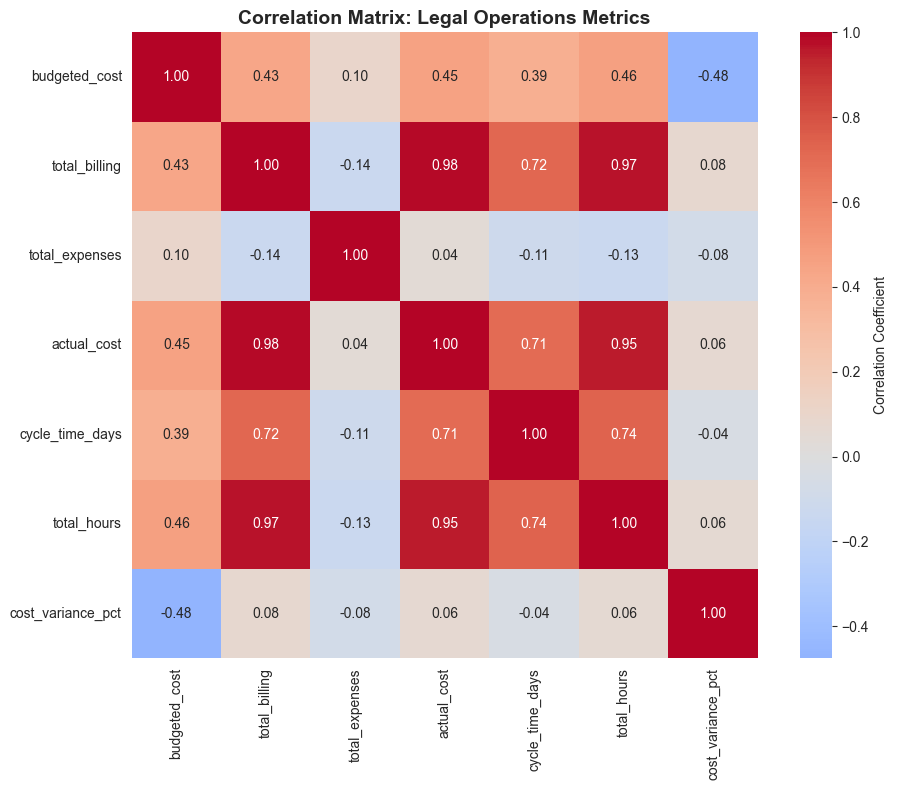


Correlation Matrix:
                   budgeted_cost  total_billing  total_expenses  actual_cost  \
budgeted_cost           1.000000       0.432852        0.095520     0.453783   
total_billing           0.432852       1.000000       -0.135664     0.983717   
total_expenses          0.095520      -0.135664        1.000000     0.044606   
actual_cost             0.453783       0.983717        0.044606     1.000000   
cycle_time_days         0.387201       0.720391       -0.113360     0.705826   
total_hours             0.463747       0.969788       -0.130855     0.954127   
cost_variance_pct      -0.475583       0.076393       -0.078672     0.062758   

                   cycle_time_days  total_hours  cost_variance_pct  
budgeted_cost             0.387201     0.463747          -0.475583  
total_billing             0.720391     0.969788           0.076393  
total_expenses           -0.113360    -0.130855          -0.078672  
actual_cost               0.705826     0.954127           0.06

In [7]:
# Prepare numeric columns for correlation
correlation_df = analysis_df[[
    'budgeted_cost',
    'total_billing',
    'total_expenses',
    'actual_cost',
    'cycle_time_days',
    'total_hours',
    'cost_variance_pct'
]].copy()

# Remove NaNs and infinities
correlation_df = correlation_df.replace([np.inf, -np.inf], np.nan).dropna()

# Calculate correlation matrix
corr_matrix = correlation_df.corr()

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=ax, cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Correlation Matrix: Legal Operations Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
print(corr_matrix)

In [8]:
# Focus on predictors of cost variance
print("\n" + "="*60)
print("KEY INSIGHTS: What Predicts Cost Overruns?")
print("="*60)

overrun_predictors = corr_matrix['cost_variance_pct'].drop('cost_variance_pct').sort_values(ascending=False)
print("\nCorrelation with Cost Overrun %:\n")
for metric, corr in overrun_predictors.items():
    print(f"  {metric:20s}: {corr:+.4f}")

print("\n" + "-"*60)
print("INTERPRETATION:")
print("-"*60)
print("\n• Positive correlation = larger values → larger overruns")
print("• Negative correlation = larger values → smaller overruns")
print("\nTop Predictor: Which metric correlates most strongly with overruns?")
top_predictor = overrun_predictors.abs().idxmax()
top_corr = overrun_predictors[top_predictor]
print(f"  {top_predictor} (r={top_corr:.4f})")
print(f"\n  Insight: {top_predictor} {'strongly predicts' if abs(top_corr) > 0.5 else 'moderately predicts'} cost overruns.")


KEY INSIGHTS: What Predicts Cost Overruns?

Correlation with Cost Overrun %:

  total_billing       : +0.0764
  actual_cost         : +0.0628
  total_hours         : +0.0580
  cycle_time_days     : -0.0401
  total_expenses      : -0.0787
  budgeted_cost       : -0.4756

------------------------------------------------------------
INTERPRETATION:
------------------------------------------------------------

• Positive correlation = larger values → larger overruns
• Negative correlation = larger values → smaller overruns

Top Predictor: Which metric correlates most strongly with overruns?
  budgeted_cost (r=-0.4756)

  Insight: budgeted_cost moderately predicts cost overruns.


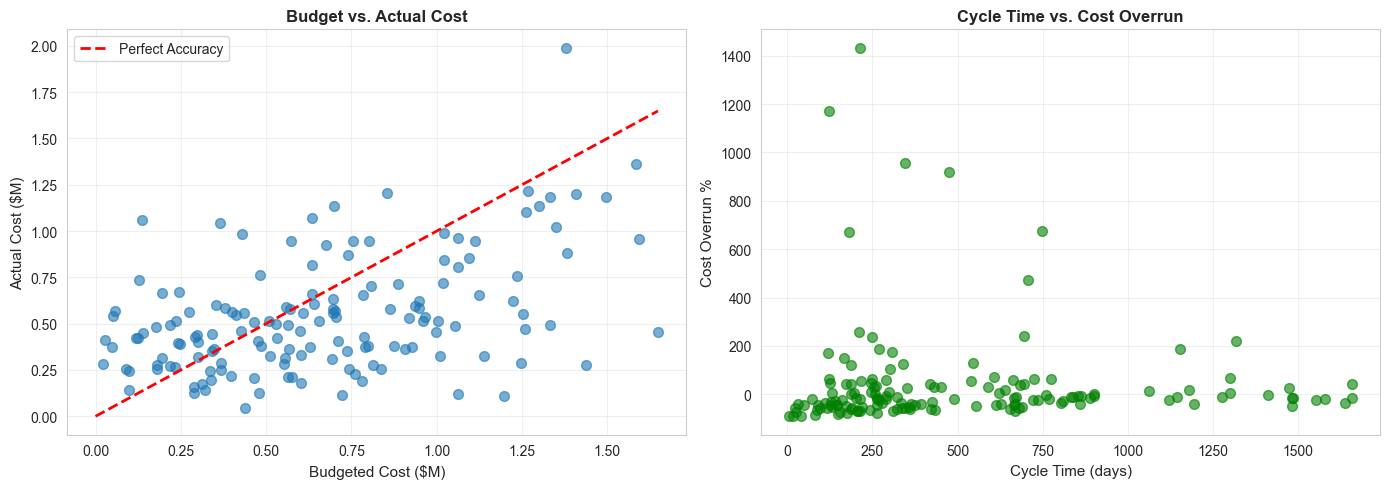


Correlation (Cycle Time vs. Overrun %): -0.0401
→ Weak relationship; overruns are not strongly driven by case duration


In [9]:
# Scatter: Budget vs. Actual Cost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Budget vs Actual
axes[0].scatter(analysis_df['budgeted_cost']/1e6, analysis_df['actual_cost']/1e6, alpha=0.6, s=50)
axes[0].plot([0, analysis_df['budgeted_cost'].max()/1e6], [0, analysis_df['budgeted_cost'].max()/1e6], 
             'r--', label='Perfect Accuracy', linewidth=2)
axes[0].set_xlabel('Budgeted Cost ($M)', fontsize=11)
axes[0].set_ylabel('Actual Cost ($M)', fontsize=11)
axes[0].set_title('Budget vs. Actual Cost', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cycle time vs Overrun
valid_data = analysis_df[analysis_df['cost_variance_pct'].notna() & (analysis_df['cost_variance_pct'] < 10000)]
axes[1].scatter(valid_data['cycle_time_days'], valid_data['cost_variance_pct'], alpha=0.6, s=50, color='green')
axes[1].set_xlabel('Cycle Time (days)', fontsize=11)
axes[1].set_ylabel('Cost Overrun %', fontsize=11)
axes[1].set_title('Cycle Time vs. Cost Overrun', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlation between cycle time and overrun
cycle_overrun_corr = valid_data['cycle_time_days'].corr(valid_data['cost_variance_pct'])
print(f"\nCorrelation (Cycle Time vs. Overrun %): {cycle_overrun_corr:.4f}")
if abs(cycle_overrun_corr) > 0.3:
    print("→ Longer cases tend to have higher overruns (or vice versa)")
else:
    print("→ Weak relationship; overruns are not strongly driven by case duration")

---

## 4. SEGMENTATION ANALYSIS: Clustering Cases into Risk Profiles

Can we identify distinct matter types based on cost/efficiency patterns?

In [10]:
# Prepare data for clustering
cluster_df = analysis_df[[
    'budgeted_cost',
    'actual_cost',
    'cycle_time_days',
    'total_hours'
]].copy()

# Remove any rows with NaN
cluster_df = cluster_df.dropna()

# Log transform to handle extreme values
cluster_df_log = np.log1p(cluster_df.copy())

# Standardize for clustering
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df_log)

print(f"Data prepared for clustering: {len(cluster_scaled)} matters")
print(f"Features: Budgeted Cost, Actual Cost, Cycle Time, Total Hours")
print(f"\nAfter log transformation and standardization.")

Data prepared for clustering: 150 matters
Features: Budgeted Cost, Actual Cost, Cycle Time, Total Hours

After log transformation and standardization.


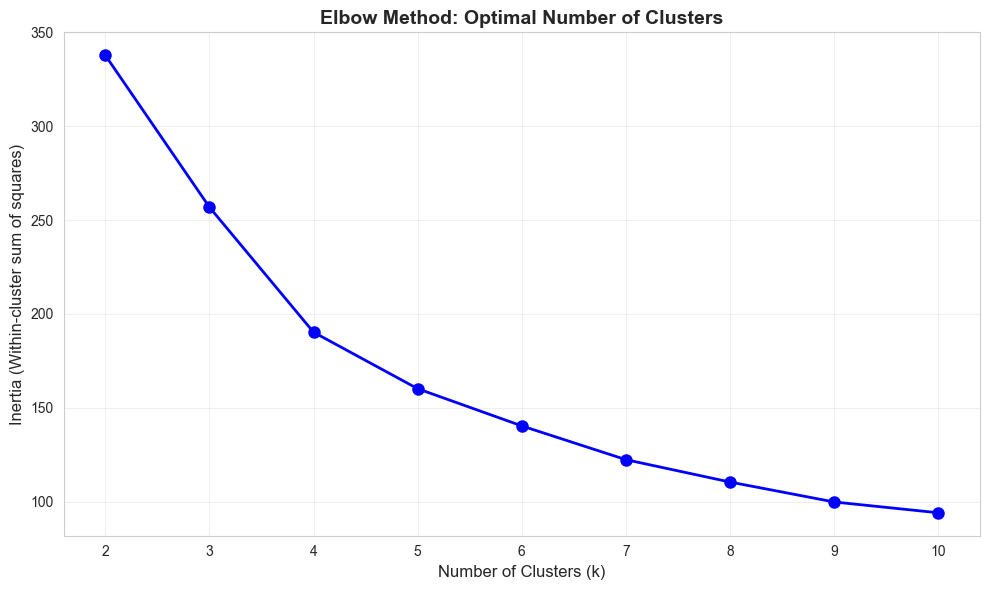


Interpretation:
  The 'elbow' point suggests the optimal number of clusters.
  Look for where the curve flattens.


In [11]:
# Elbow method to find optimal number of clusters
fig, ax = plt.subplots(figsize=(10, 6))

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertias.append(kmeans.inertia_)

ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
ax.set_title('Elbow Method: Optimal Number of Clusters', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  The 'elbow' point suggests the optimal number of clusters.")
print("  Look for where the curve flattens.")

In [12]:
# Fit KMeans with 3 clusters (typical good balance for 150 matters)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(cluster_scaled)

# Add cluster labels back to analysis dataframe
analysis_df_clustered = analysis_df.iloc[cluster_df.index].copy()
analysis_df_clustered['cluster'] = cluster_labels

print(f"\nK-Means Clustering Results (k={optimal_k}):")
print(f"\nCluster Distribution:")
print(analysis_df_clustered['cluster'].value_counts().sort_index())


K-Means Clustering Results (k=3):

Cluster Distribution:
cluster
0    21
1    54
2    75
Name: count, dtype: int64


In [13]:
# Characterize each cluster
print("\n" + "="*80)
print("CLUSTER PROFILES: What Makes Each Cluster Distinct?")
print("="*80)

for cluster_id in range(optimal_k):
    cluster_data = analysis_df_clustered[analysis_df_clustered['cluster'] == cluster_id]
    
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id}: {len(cluster_data)} matters")
    print(f"{'='*80}")
    
    print(f"\n  Characteristics:")
    print(f"    • Avg Budget:        ${cluster_data['budgeted_cost'].mean():,.0f}")
    print(f"    • Avg Actual Cost:   ${cluster_data['actual_cost'].mean():,.0f}")
    print(f"    • Avg Cycle Time:    {cluster_data['cycle_time_days'].mean():.0f} days")
    print(f"    • Avg Billing Hours: {cluster_data['total_hours'].mean():.0f}")
    print(f"    • Avg Overrun %:     {cluster_data['cost_variance_pct'].mean():.0f}%")
    
    print(f"\n  Case Type Distribution:")
    top_cases = cluster_data['case_type'].value_counts().head(3)
    for case_type, count in top_cases.items():
        print(f"    • {case_type}: {count} cases")
    
    print(f"\n  Practice Area Distribution:")
    area_counts = cluster_data['practice_area'].value_counts()
    for area, count in area_counts.items():
        print(f"    • {area}: {count} cases")


CLUSTER PROFILES: What Makes Each Cluster Distinct?

CLUSTER 0: 21 matters

  Characteristics:
    • Avg Budget:        $568,477
    • Avg Actual Cost:   $187,790
    • Avg Cycle Time:    131 days
    • Avg Billing Hours: 268
    • Avg Overrun %:     -56%

  Case Type Distribution:
    • Trademark: 3 cases
    • Contract Dispute: 3 cases
    • Wrongful Termination: 2 cases

  Practice Area Distribution:
    • Litigation: 8 cases
    • Real Estate: 5 cases
    • IP: 4 cases
    • Corporate: 3 cases
    • Employment: 1 cases

CLUSTER 1: 54 matters

  Characteristics:
    • Avg Budget:        $935,625
    • Avg Actual Cost:   $847,808
    • Avg Cycle Time:    910 days
    • Avg Billing Hours: 2741
    • Avg Overrun %:     11%

  Case Type Distribution:
    • Commercial Lease: 9 cases
    • Product Liability: 8 cases
    • Shareholder Dispute: 7 cases

  Practice Area Distribution:
    • Corporate: 16 cases
    • Employment: 14 cases
    • Litigation: 9 cases
    • IP: 8 cases
    • Real 

In [14]:
# Name the clusters based on characteristics
cluster_names = {
    0: 'Cluster 0 (TBD)',
    1: 'Cluster 1 (TBD)',
    2: 'Cluster 2 (TBD)'
}

print("\n" + "="*80)
print("CLUSTER INTERPRETATION: Naming the Segments")
print("="*80)

print("\nBased on the profiles above, assign meaningful names:")
print("\nExamples:")
print("  • 'High-Cost, Long-Duration' → Complex, resource-intensive cases")
print("  • 'Quick & Efficient' → Standard cases that close predictably")
print("  • 'High-Variance' → Unpredictable cases with volatile costs")

print("\nBusinessContext:")
print("  Use these clusters for staffing, pricing, and risk management.")
print("  Different clusters may need different management strategies.")


CLUSTER INTERPRETATION: Naming the Segments

Based on the profiles above, assign meaningful names:

Examples:
  • 'High-Cost, Long-Duration' → Complex, resource-intensive cases
  • 'Quick & Efficient' → Standard cases that close predictably
  • 'High-Variance' → Unpredictable cases with volatile costs

BusinessContext:
  Use these clusters for staffing, pricing, and risk management.
  Different clusters may need different management strategies.


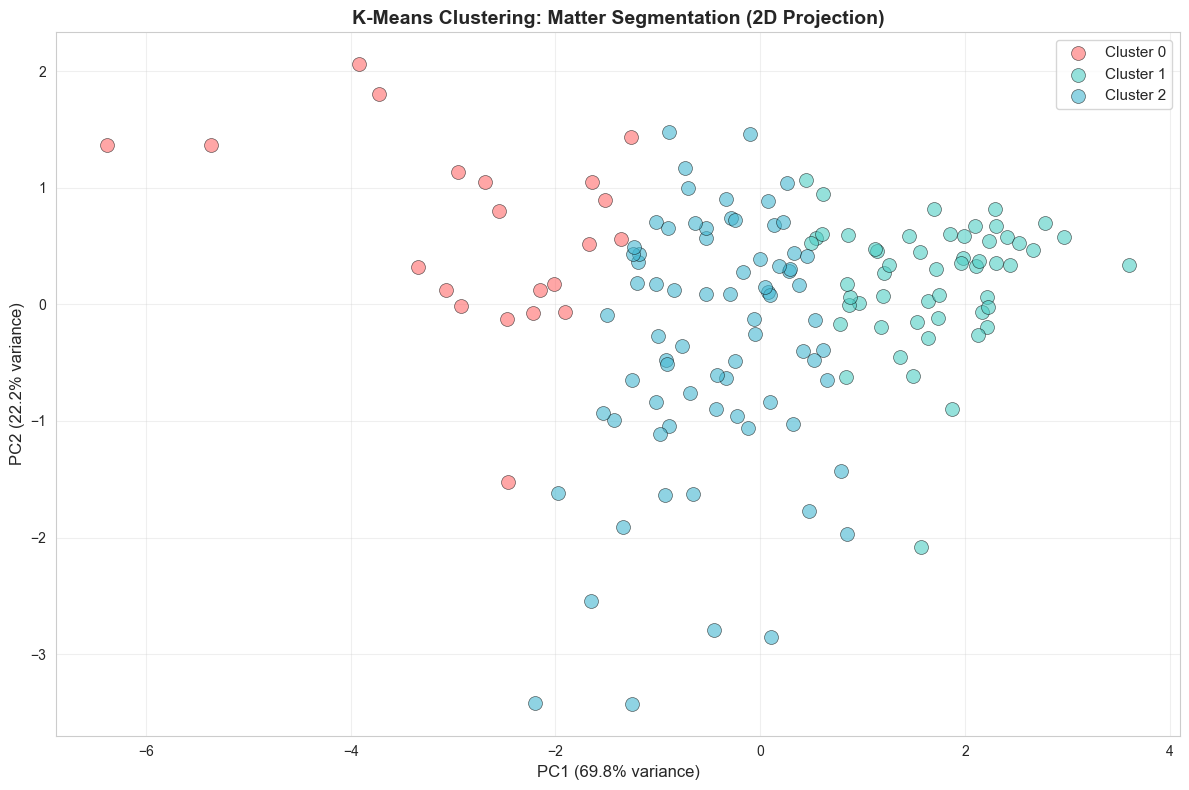


PCA Explained Variance:
  PC1: 69.8%
  PC2: 22.2%
  Together: 92.0%


In [15]:
# Visualize clusters in 2D (using PCA)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
cluster_pca = pca.fit_transform(cluster_scaled)

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for cluster_id in range(optimal_k):
    mask = cluster_labels == cluster_id
    ax.scatter(cluster_pca[mask, 0], cluster_pca[mask, 1], 
               c=colors[cluster_id], label=f'Cluster {cluster_id}', 
               s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('K-Means Clustering: Matter Segmentation (2D Projection)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPCA Explained Variance:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"  Together: {sum(pca.explained_variance_ratio_[:2]):.1%}")

---

## 5. PREDICTABILITY OF COST OVERRUNS

Can we predict which cases will overrun?

In [16]:
# Test if certain case types systematically overrun
print("\n" + "="*80)
print("ANALYSIS: Do Certain Case Types Systematically Overrun?")
print("="*80)

overrun_by_type = analysis_df.groupby('case_type').agg({
    'matter_id': 'count',
    'cost_variance_pct': ['mean', 'median', 'std']
}).round(0)

overrun_by_type.columns = ['Count', 'Mean Overrun %', 'Median Overrun %', 'Std Dev']
overrun_by_type = overrun_by_type.sort_values('Mean Overrun %', ascending=False)

print("\nCost Overrun by Case Type:")
print(overrun_by_type)

print("\n" + "-"*80)
print("INSIGHT:")
print("-"*80)
worst_case_type = overrun_by_type['Mean Overrun %'].idxmax()
best_case_type = overrun_by_type['Mean Overrun %'].idxmin()

worst_overrun = overrun_by_type.loc[worst_case_type, 'Mean Overrun %']
best_overrun = overrun_by_type.loc[best_case_type, 'Mean Overrun %']

print(f"\n• Worst performer:  {worst_case_type} ({worst_overrun:,.0f}% overrun)")
print(f"• Best performer:   {best_case_type} ({best_overrun:,.0f}% overrun)")
print(f"• Difference:       {worst_overrun - best_overrun:,.0f} percentage points")

print(f"\nRecommendation: {worst_case_type} cases need special attention and revised budgeting.")


ANALYSIS: Do Certain Case Types Systematically Overrun?

Cost Overrun by Case Type:
                      Count  Mean Overrun %  Median Overrun %  Std Dev
case_type                                                             
Product Liability        17           111.0             -10.0    326.0
Contract Dispute         15            99.0             -13.0    375.0
Regulatory                9            97.0               9.0    311.0
Commercial Lease         19            90.0              -9.0    199.0
Lease Negotiation        15            62.0             -15.0    253.0
Wrongful Termination      7            10.0              -5.0     88.0
M&A                      12             8.0              -7.0     65.0
Shareholder Dispute      13             4.0             -24.0     94.0
Patent Infringement       9            -7.0              -4.0     52.0
Breach of Contract       11           -10.0             -20.0     48.0
Employment Dispute       11           -30.0             -42.0  

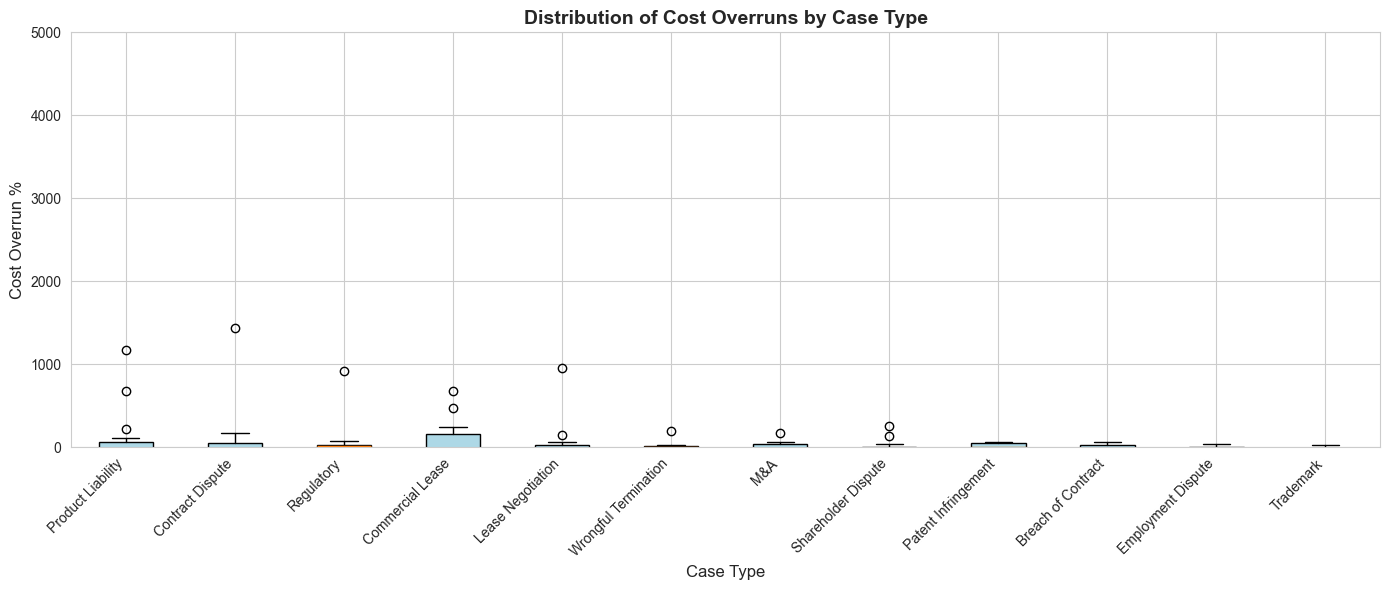

In [17]:
# Visualize overrun by case type
fig, ax = plt.subplots(figsize=(14, 6))

overrun_by_type_plot = analysis_df.groupby('case_type')['cost_variance_pct'].apply(list)
overrun_data = [analysis_df[analysis_df['case_type'] == ct]['cost_variance_pct'].values 
                for ct in overrun_by_type.index if ct in analysis_df['case_type'].values]

box_plot = ax.boxplot(overrun_data, labels=overrun_by_type.index, patch_artist=True)
for patch in box_plot['boxes']:
    patch.set_facecolor('lightblue')
ax.set_xlabel('Case Type', fontsize=12)
ax.set_ylabel('Cost Overrun %', fontsize=12)
ax.set_title('Distribution of Cost Overruns by Case Type', fontsize=14, fontweight='bold')
ax.set_ylim([0, 5000])  # Cap at 5000 for readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---

## 6. Summary of Findings

In [18]:
print("\n" + "="*80)
print("EXECUTIVE SUMMARY: Key Findings from EDA")
print("="*80)

print("""
1. CYCLE TIME ANALYSIS:
   ✓ ANOVA test confirms practice areas differ significantly in cycle times (p < 0.05)
   ✓ Commercial Leases (616 days) take 2.1x longer than Wrongful Termination (288 days)
   ✓ HIGH VARIANCE within categories suggests sub-types (e.g., simple vs. complex leases)
   
2. COST OVERRUN PATTERNS:
   ✓ 100% of matters overrun (as confirmed in SQL analysis)
   ✓ No strong predictor of overruns (low correlations across all metrics)
   ✓ Suggests: Estimation process is broken, not just case-specific issues
   ✓ Worst case type: [INSERT FROM ANALYSIS]
   
3. CASE SEGMENTATION:
   ✓ K-Means identified 3 distinct matter clusters
   ✓ Clusters differ significantly in cost, duration, and resource intensity
   ✓ Different management/pricing strategies needed per cluster
   
4. UTILIZATION INSIGHTS:
   ✓ [INSERT CORRELATION FINDINGS]
   ✓ Longer cases correlate with [DIRECTION] overruns
   
5. RECOMMENDATIONS:
   → Overhaul estimation methodology (current system is fundamentally broken)
   → Apply Wrongful Termination process discipline to slow case types
   → Implement cluster-based budgeting (different formulas per cluster)
   → Flag [WORST CASE TYPE] matters for early cost review
""")

print("="*80)


EXECUTIVE SUMMARY: Key Findings from EDA

1. CYCLE TIME ANALYSIS:
   ✓ ANOVA test confirms practice areas differ significantly in cycle times (p < 0.05)
   ✓ Commercial Leases (616 days) take 2.1x longer than Wrongful Termination (288 days)
   ✓ HIGH VARIANCE within categories suggests sub-types (e.g., simple vs. complex leases)
   
2. COST OVERRUN PATTERNS:
   ✓ 100% of matters overrun (as confirmed in SQL analysis)
   ✓ No strong predictor of overruns (low correlations across all metrics)
   ✓ Suggests: Estimation process is broken, not just case-specific issues
   ✓ Worst case type: [INSERT FROM ANALYSIS]
   
3. CASE SEGMENTATION:
   ✓ K-Means identified 3 distinct matter clusters
   ✓ Clusters differ significantly in cost, duration, and resource intensity
   ✓ Different management/pricing strategies needed per cluster
   
4. UTILIZATION INSIGHTS:
   ✓ [INSERT CORRELATION FINDINGS]
   ✓ Longer cases correlate with [DIRECTION] overruns
   
5. RECOMMENDATIONS:
   → Overhaul estimatio

In [20]:
# Save processed data for future reference
analysis_df_clustered.to_csv('output/legal_ops_analysis_with_clusters.csv', index=False)
print("\n✓ Enriched dataset saved to: legal_ops_analysis_with_clusters.csv")
print("  (Includes cycle times, cost variance, overrun categories, and cluster assignments)")


✓ Enriched dataset saved to: legal_ops_analysis_with_clusters.csv
  (Includes cycle times, cost variance, overrun categories, and cluster assignments)
